Power-law fits S(x) ≈ A x^alpha (using x <= 0.300)
S(ρ1 || ρ0)  (sigma || vacuum):  A = 9.098104e-01, alpha = 2.037088
S(ρ2 || ρ0)  (epsilon || vacuum):A = 2.383038e+01, alpha = 3.746674
S(ρ1 || ρ2)  (sigma || epsilon): A = 5.615147e+00, alpha = 2.840819


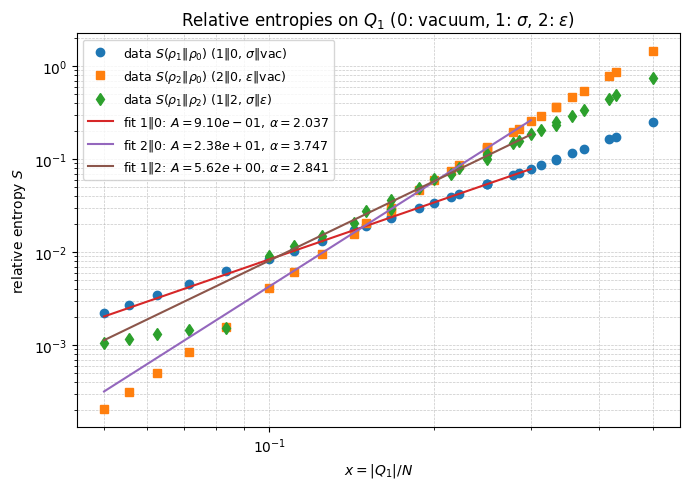

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def power_law_fit(x, y):
    """
    Fit y ~ A * x^alpha using linear regression on log-log data.
    Returns (A, alpha).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    mask = (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    logx = np.log(x)
    logy = np.log(y)

    # Linear fit: log y = log A + alpha * log x
    A_mat = np.vstack([np.ones_like(logx), logx]).T
    beta, alpha = np.linalg.lstsq(A_mat, logy, rcond=None)[0]
    A = np.exp(beta)
    return A, alpha


# -----------------------------
# 1. Hard-code your data table
# -----------------------------
# Columns: N, x, S(ρ1||ρ0), S(ρ2||ρ0), S(ρ1||ρ2)
rows = [
        # N = 12
        (12, 0.083333, 6.2787131810e-03, 1.5507376175e-03, 1.5456497316e-03),
        (12, 0.166667, 2.3817047647e-02, 2.8014952138e-02, 2.9403301814e-02),
        (12, 0.250000, 5.4235194947e-02, 1.2963497126e-01, 1.0137071390e-01),
        (12, 0.333333, 9.9406872534e-02, 3.6011981560e-01, 2.3300769859e-01),
        (12, 0.416667, 1.6283172996e-01, 7.7615987964e-01, 4.4001409288e-01),
        (12, 0.500000, 2.5054004404e-01, 1.4444075035e+00, 7.4435539144e-01),

        # N = 14
        (14, 0.071429, 4.5645765241e-03, 8.4385042135e-04, 1.4527578309e-03),
        (14, 0.142857, 1.7370540319e-02, 1.5825199814e-02, 2.0487550000e-02),
        (14, 0.214286, 3.9347015191e-02, 7.4952737646e-02, 6.8407985157e-02),
        (14, 0.285714, 7.1422002450e-02, 2.1159051494e-01, 1.5565139380e-01),
        (14, 0.357143, 1.1526933414e-01, 4.6031256794e-01, 2.9144952810e-01),
        (14, 0.428571, 1.7350079799e-01, 8.5793800584e-01, 4.8631990610e-01),

        # N = 16
        (16, 0.062500, 3.4673167198e-03, 4.9750874307e-04, 1.3165474186e-03),
        (16, 0.125000, 1.3232491192e-02, 9.5912641897e-03, 1.5067822646e-02),
        (16, 0.187500, 2.9878994178e-02, 4.6305240214e-02, 4.8814136665e-02),
        (16, 0.250000, 5.3916608343e-02, 1.3261913579e-01, 1.1001587551e-01),
        (16, 0.312500, 8.6254347571e-02, 2.9141236030e-01, 2.0491074490e-01),
        (16, 0.375000, 1.2823461671e-01, 5.4622028533e-01, 3.3974661205e-01),

        # N = 18
        (18, 0.055556, 2.7230008031e-03, 3.1171487963e-04, 1.1767674157e-03),
        (18, 0.111111, 1.0417441879e-02, 6.1403497793e-03, 1.1539473275e-02),
        (18, 0.166667, 2.3474602516e-02, 3.0117606705e-02, 3.6345099246e-02),
        (18, 0.222222, 4.2196810730e-02, 8.7360573906e-02, 8.1138000248e-02),
        (18, 0.277778, 6.7124818472e-02, 1.9380366863e-01, 1.5046122066e-01),
        (18, 0.333333, 9.9023616263e-02, 3.6568304338e-01, 2.4855821652e-01),

        # N = 20
        (20, 0.050000, 2.1948451212e-03, 2.0508127837e-04, 1.0469537960e-03),
        (20, 0.100000, 8.4146740685e-03, 4.1074363354e-03, 9.1181662873e-03),
        (20, 0.150000, 1.8935536165e-02, 2.0414376598e-02, 2.7982070172e-02),
        (20, 0.200000, 3.3947752856e-02, 5.9876445991e-02, 6.1871797682e-02),
        (20, 0.250000, 5.3792406761e-02, 1.3400380560e-01, 1.1426079234e-01),
        (20, 0.300000, 7.8939020363e-02, 2.5452326481e-01, 1.8826182528e-01),
    ]

rows = np.array(rows)
N_all   = rows[:, 0]
x_all   = rows[:, 1]
S10_all = rows[:, 2]  # S(ρ1 || ρ0): sigma vs vacuum
S20_all = rows[:, 3]  # S(ρ2 || ρ0): epsilon vs vacuum
S12_all = rows[:, 4]  # S(ρ1 || ρ2): sigma vs epsilon

# -----------------------------------------
# 2. Choose small-x window for power-law fit
# -----------------------------------------
x_max_fit = 0.3
x_min_fit = 0.1
fit_mask = (x_min_fit < x_all) & (x_all <= x_max_fit)

x_fit   = x_all[fit_mask]
S10_fit = S10_all[fit_mask]
S20_fit = S20_all[fit_mask]
S12_fit = S12_all[fit_mask]

# -----------------------------------------
# 3. Do the power-law fits on small-x data
# -----------------------------------------
A10, alpha10 = power_law_fit(x_fit, S10_fit)  # 1 vs 0 (sigma vs vacuum)
A20, alpha20 = power_law_fit(x_fit, S20_fit)  # 2 vs 0 (epsilon vs vacuum)
A12, alpha12 = power_law_fit(x_fit, S12_fit)  # 1 vs 2 (sigma vs epsilon)

print("Power-law fits S(x) ≈ A x^alpha (using x <= {:.3f})".format(x_max_fit))
print("S(ρ1 || ρ0)  (sigma || vacuum):  A = {:.6e}, alpha = {:.6f}".format(A10, alpha10))
print("S(ρ2 || ρ0)  (epsilon || vacuum):A = {:.6e}, alpha = {:.6f}".format(A20, alpha20))
print("S(ρ1 || ρ2)  (sigma || epsilon): A = {:.6e}, alpha = {:.6f}".format(A12, alpha12))

# -----------------------------------------
# 4. Make log-log plot with fits and labels
# -----------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

# Data points (all N)
ax.loglog(x_all, S10_all, "o", label=r"data $S(\rho_1\Vert\rho_0)$ (1‖0, $\sigma$‖vac)")
ax.loglog(x_all, S20_all, "s", label=r"data $S(\rho_2\Vert\rho_0)$ (2‖0, $\varepsilon$‖vac)")
ax.loglog(x_all, S12_all, "d", label=r"data $S(\rho_1\Vert\rho_2)$ (1‖2, $\sigma$‖$\varepsilon$)")

# Smooth x-range for plotting the fits
x_min_plot = x_all.min()
x_max_plot = x_max_fit  # show fits only in the small-x window
x_line = np.logspace(np.log10(x_min_plot), np.log10(x_max_plot), 200)

y10_line = A10 * x_line**alpha10
y20_line = A20 * x_line**alpha20
y12_line = A12 * x_line**alpha12

# Fit curves with alpha in legend
lbl10_fit = r"fit 1‖0: $A={:.2e},\, \alpha={:.3f}$".format(A10, alpha10)
lbl20_fit = r"fit 2‖0: $A={:.2e},\, \alpha={:.3f}$".format(A20, alpha20)
lbl12_fit = r"fit 1‖2: $A={:.2e},\, \alpha={:.3f}$".format(A12, alpha12)

ax.loglog(x_line, y10_line, "-", label=lbl10_fit)
ax.loglog(x_line, y20_line, "-", label=lbl20_fit)
ax.loglog(x_line, y12_line, "-", label=lbl12_fit)

ax.set_xlabel(r"$x = |Q_1|/N$")
ax.set_ylabel(r"relative entropy $S$")
ax.set_title(r"Relative entropies on $Q_1$ (0: vacuum, 1: $\sigma$, 2: $\varepsilon$)")
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.show()

